In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import (
    linkage,
    dendrogram
)

from scipy.spatial.distance import (
    squareform
)

from pandas.plotting import parallel_coordinates

In [2]:
from google.colab import files

uploaded = files.upload()

Saving phase2_results.xlsx to phase2_results.xlsx


In [3]:
from google.colab import files

uploaded = files.upload()

Saving phase3_results.xlsx to phase3_results.xlsx


In [4]:
# =========================
# CONFIGURATION
# =========================

PHASE2_FILE = "phase2_results.xlsx"
PHASE3_FILE = "phase3_results.xlsx"

MODEL_COLUMN = "Model"
CONSENSUS_COLUMN = "Overall_Consensus_Rank"

OUTPUT_DIR = "visualizations"

In [5]:
RANK_COLUMNS = [
    "MARCOS",
    "SECA",
    "MUTRISS",
    "MAIRCA",
    "CODAS",
    "RAFSI",
    "CRADIS",
    "CoCoSo",
    "MABAC",
    "COPRAS",
    "RAM",
    "WASPAS",
    "PIV",
    "WISP"
]


In [6]:
import os

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

In [7]:
PHASE2_FILE = "phase2_results.xlsx"
PHASE3_FILE = "phase3_results.xlsx"

In [8]:
df = pd.read_excel(
    PHASE2_FILE
)

spearman_matrix = pd.read_excel(
    PHASE3_FILE,
    sheet_name="Spearman",
    index_col=0
)

kendall_matrix = pd.read_excel(
    PHASE3_FILE,
    sheet_name="Kendall",
    index_col=0
)

phase3_summary = pd.read_excel(
    PHASE3_FILE,
    sheet_name="Phase3_Summary"
)

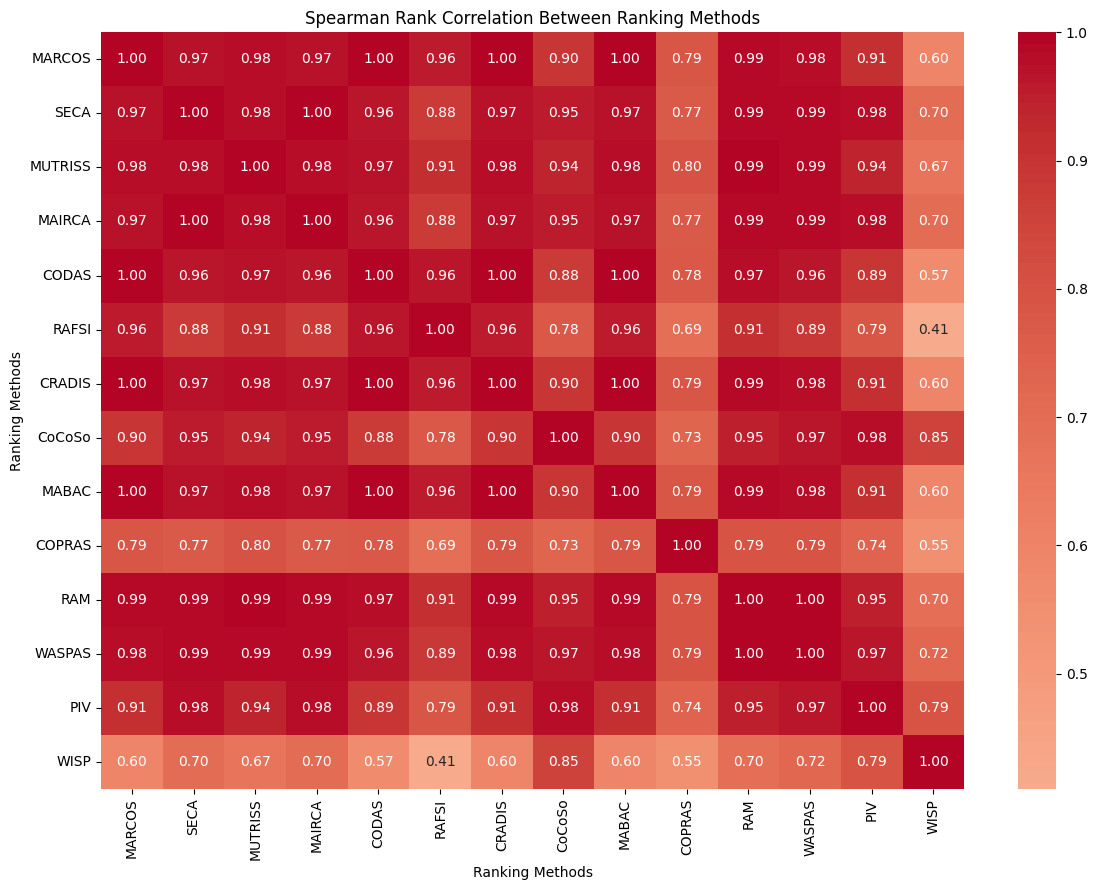

In [9]:
# step 15 - heatmap

plt.figure(figsize=(12, 9))

sns.heatmap(
    spearman_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title(
    "Spearman Rank Correlation Between Ranking Methods"
)

plt.xlabel("Ranking Methods")
plt.ylabel("Ranking Methods")

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/spearman_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [10]:
#step 16 - parallel coordinates

top20 = (
    df.sort_values(CONSENSUS_COLUMN)
      .head(20)
      .copy()
)

In [13]:
CRITERIA_COLUMNS = [
    "Price (INR)",
    "RAM (GB)",
    "Battery (mAh)",
    "Camera (MP)",
    "Display (Inches)"
]

In [14]:
parallel_df = top20[
    [MODEL_COLUMN] + CRITERIA_COLUMNS
].copy()

In [15]:
for column in CRITERIA_COLUMNS:

    min_value = parallel_df[column].min()
    max_value = parallel_df[column].max()

    if max_value != min_value:

        parallel_df[column] = (
            parallel_df[column] - min_value
        ) / (
            max_value - min_value
        )

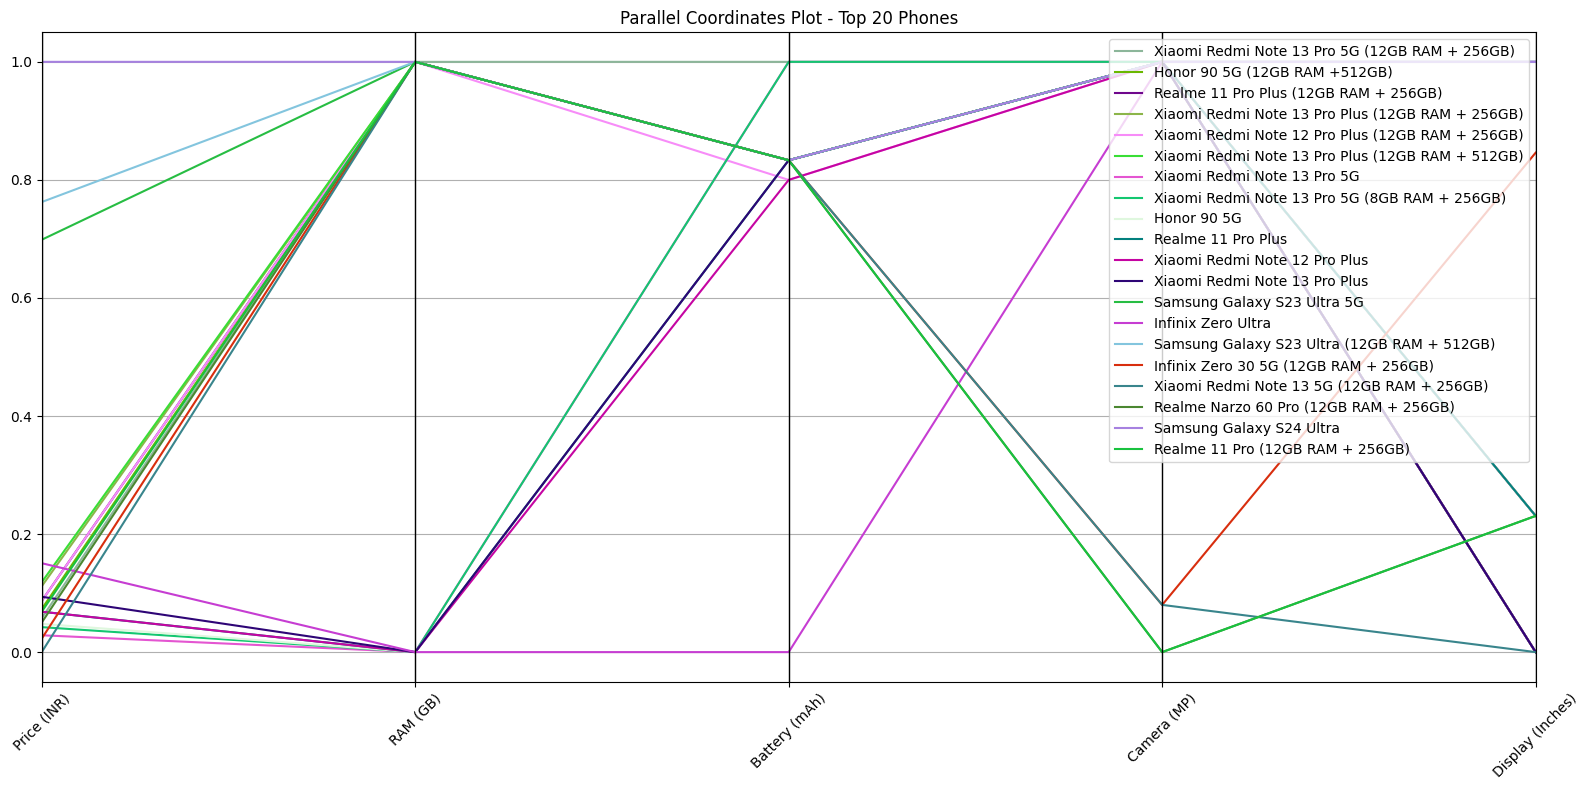

In [16]:
plt.figure(figsize=(16, 8))

parallel_coordinates(
    parallel_df,
    MODEL_COLUMN
)

plt.title(
    "Parallel Coordinates Plot - Top 20 Phones"
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/parallel_coordinates.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [17]:
#step 17 - bar char

top10 = (
    df.sort_values(CONSENSUS_COLUMN)
      .head(10)
)

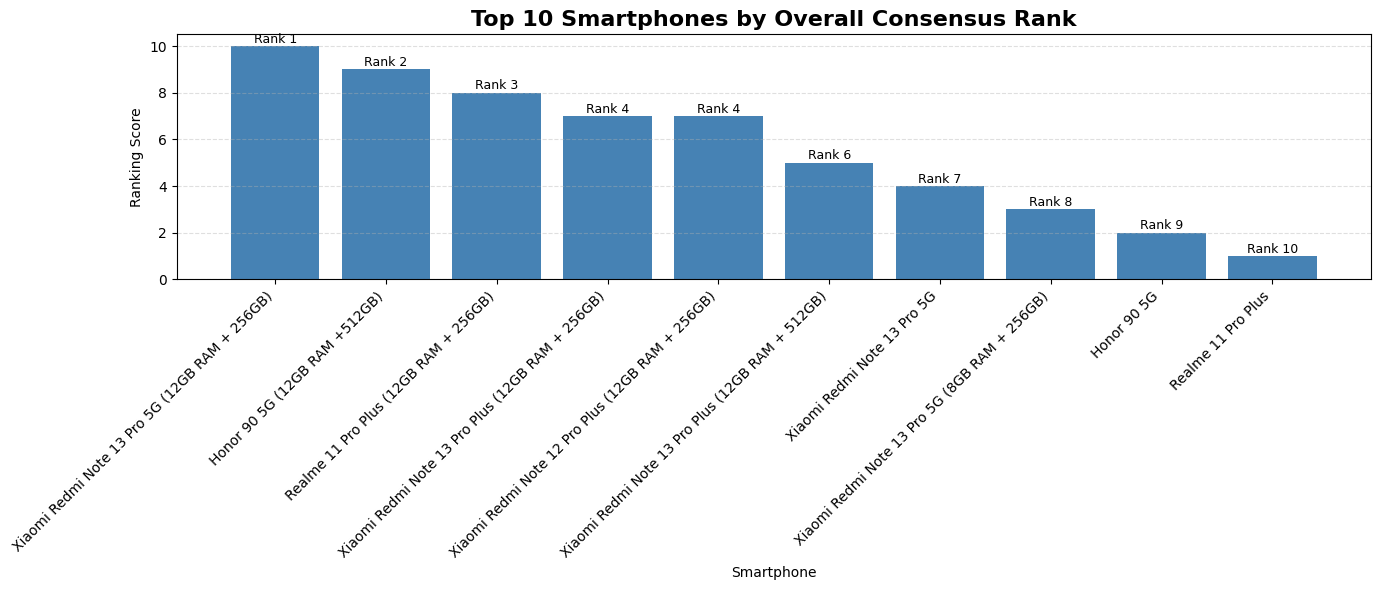

In [22]:
top10 = (
    df.sort_values(CONSENSUS_COLUMN)
      .head(10)
)

plot_values = top10[CONSENSUS_COLUMN].max() + 1 - top10[CONSENSUS_COLUMN]

plt.figure(figsize=(14,6))

plt.bar(
    top10[MODEL_COLUMN],
    plot_values,
    color="steelblue"
)

plt.title(
    "Top 10 Smartphones by Overall Consensus Rank",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Smartphone")
plt.ylabel("Ranking Score")

plt.xticks(rotation=45, ha="right")

# Show original ranks above each bar
for i, rank in enumerate(top10[CONSENSUS_COLUMN]):
    plt.text(
        i,
        plot_values.iloc[i] + 0.15,
        f"Rank {rank}",
        ha="center",
        fontsize=9
    )

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/top10_bar_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [23]:
#step 18 - box plot

boxplot_df = df[
    [MODEL_COLUMN] + RANK_COLUMNS
].melt(
    id_vars=MODEL_COLUMN,
    var_name="Method",
    value_name="Rank"
)

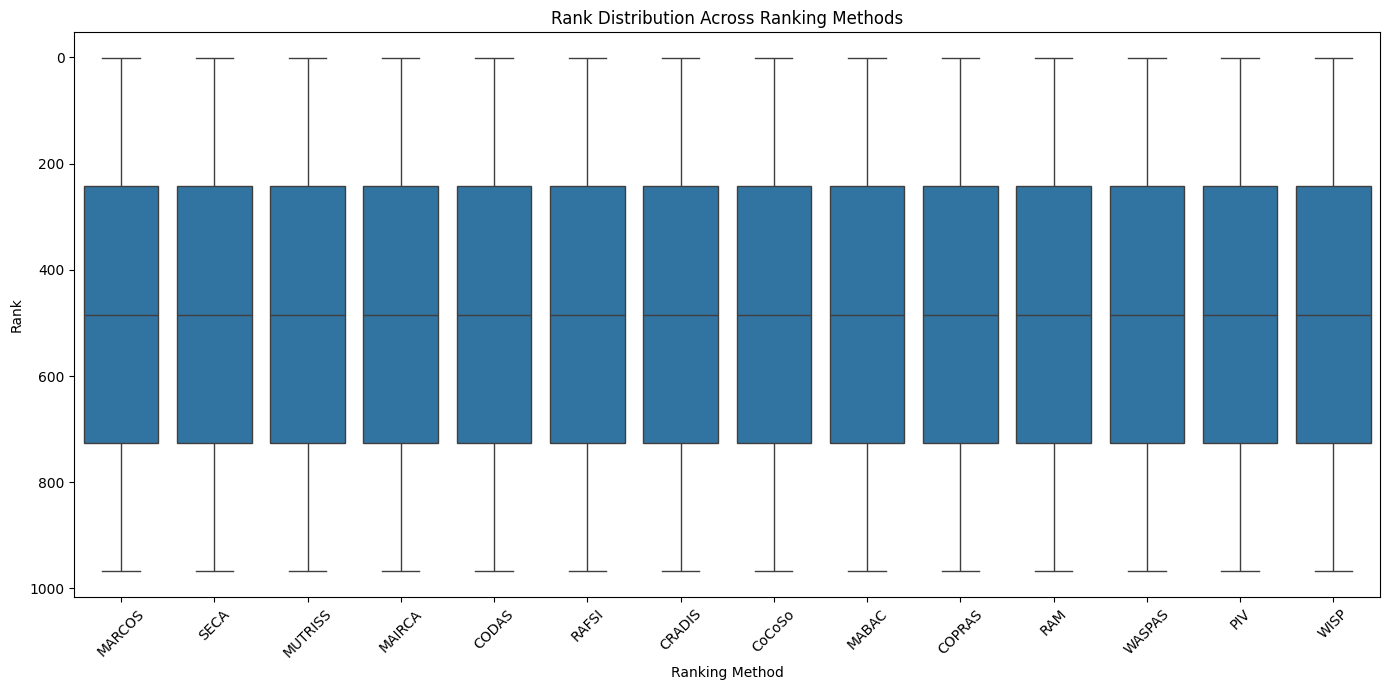

In [24]:
plt.figure(figsize=(14, 7))

sns.boxplot(
    data=boxplot_df,
    x="Method",
    y="Rank"
)

plt.title(
    "Rank Distribution Across Ranking Methods"
)

plt.xlabel("Ranking Method")
plt.ylabel("Rank")

plt.xticks(rotation=45)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/rank_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [25]:
#step 19 - scatter plot

method_x = phase3_summary.iloc[0]["Method"]
method_y = phase3_summary.iloc[1]["Method"]

print("Method X:", method_x)
print("Method Y:", method_y)

Method X: WASPAS
Method Y: RAM


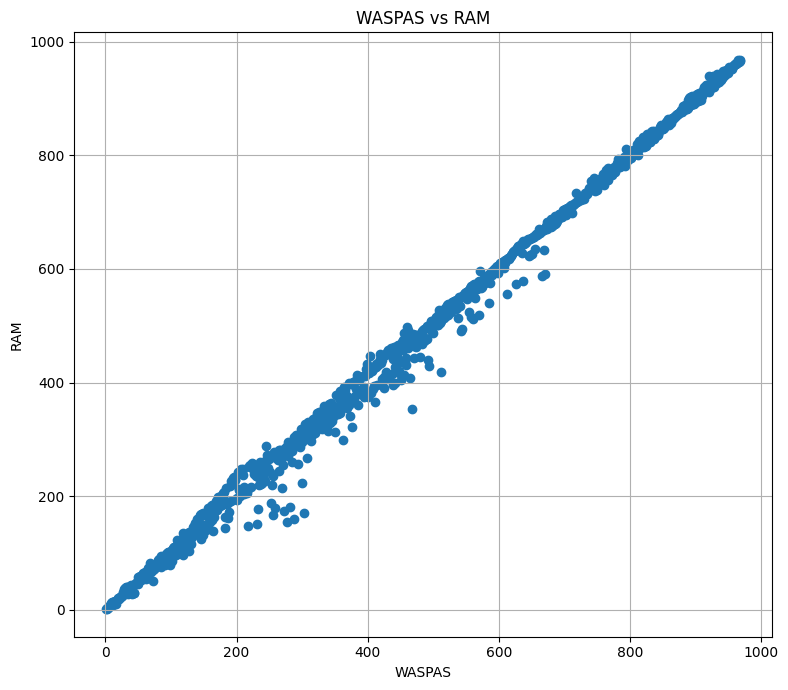

In [26]:
plt.figure(figsize=(8, 7))

plt.scatter(
    df[method_x],
    df[method_y]
)

plt.xlabel(method_x)
plt.ylabel(method_y)

plt.title(
    f"{method_x} vs {method_y}"
)

plt.grid(True)

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/method_scatter.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [27]:
# step 20 - dendrogram

distance_matrix = (
    1 - spearman_matrix
)

In [28]:
condensed_distance = squareform(
    distance_matrix,
    checks=False
)

In [29]:
linkage_matrix = linkage(
    condensed_distance,
    method="average"
)

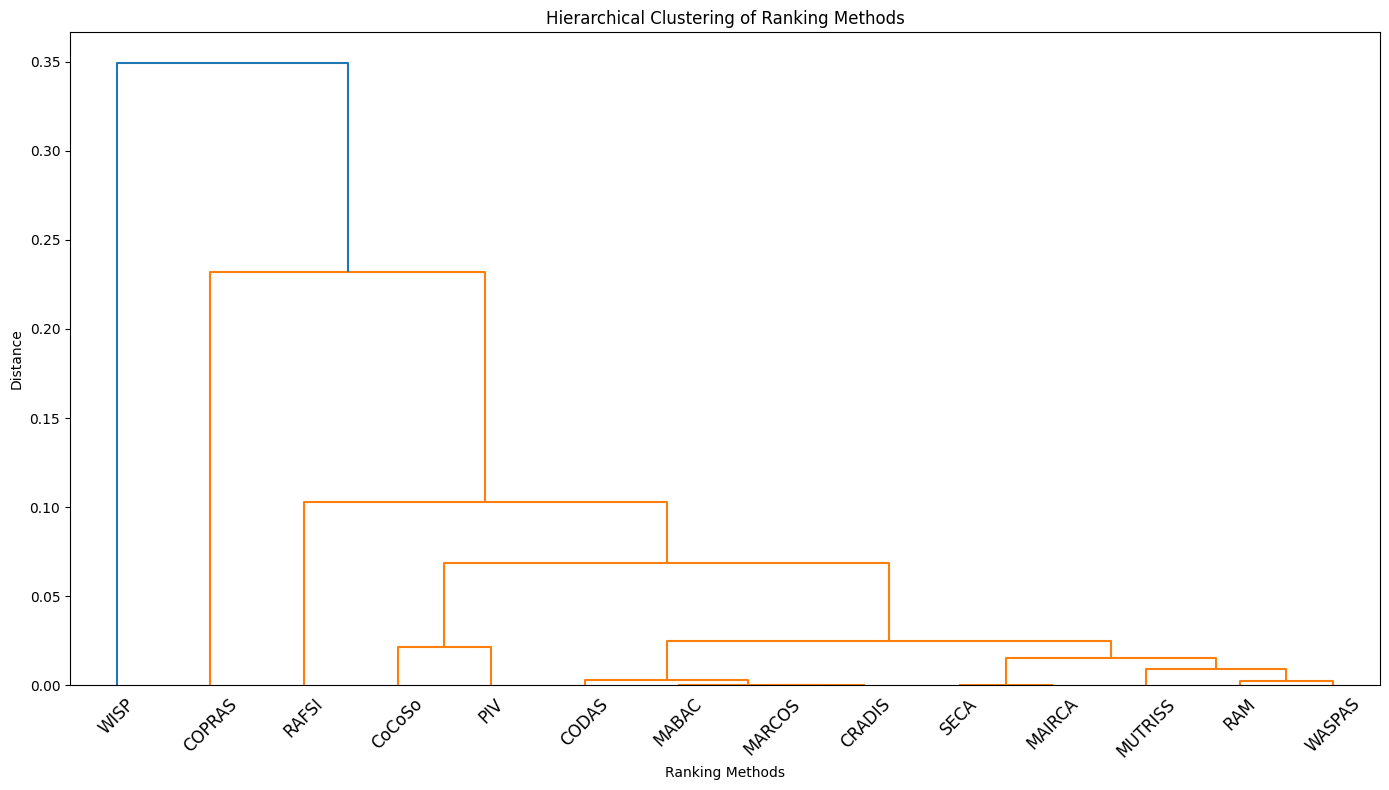

In [30]:
plt.figure(figsize=(14, 8))

dendrogram(
    linkage_matrix,
    labels=spearman_matrix.index,
    leaf_rotation=45
)

plt.title(
    "Hierarchical Clustering of Ranking Methods"
)

plt.xlabel("Ranking Methods")
plt.ylabel("Distance")

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/method_dendrogram.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [31]:
import os

OUTPUT_DIR = "visualizations"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [32]:
import shutil

shutil.make_archive(
    "visualizations",
    "zip",
    "visualizations"
)

'/content/visualizations.zip'

In [33]:
from google.colab import files

files.download("visualizations.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>